# 02 · Demographic Context: Census 2011 and 2022

Notebook 2 of 6 · **Eastern Cape Municipal Electoral Dynamics**

**What this notebook does.** It prepares municipal Census indicators and, crucially, decides *which* demographic values may be attached to *which* election, for two different jobs: describing past elections, and predicting future ones without using information that did not yet exist.

| | |
|---|---|
| **Inputs** | `data/processed/demographics/clean_census.csv` (33 municipalities, Census 2011 and 2022 indicators); optional `data/raw/registration/ec_registration_2026.csv` |
| **Outputs** | `data/processed/demographics/phase2/*.csv`, figures in `reports/figures/phase2/` |
| **Code** | `src/data/demographics.py` |

**At a glance**
- Two alignment policies: **descriptive** (interpolated 2016/2021 values, for EDA) and **as-known** (only a census already published before the election, for models).
- Between 2011 and 2022 every municipality's share of children fell and service access generally rose; the spread between municipalities remains large.
- `EC CENSUS.csv`, previously described as provincial, is in fact a **Buffalo City** table (its 2022 total equals Buffalo City's population exactly). It is documented as such and not used as provincial evidence.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


## 1. The municipal Census table

`clean_census.csv` holds ten indicators for each of the 33 municipalities in Census 2011 and Census 2022.

**Provenance flag.** The repository does not record how this file was produced or from which exact tables. Its indicators are Census-type municipal measures and Buffalo City's 2022 population matches the Buffalo City census table exactly, but the upstream source **cannot be verified from repository evidence**. It is used as documented-but-unverified context; see `docs/DATA_SOURCES.md`.

In [2]:
from src.data import demographics as D

census = D.load_census()
labels = pd.DataFrame({"Indicator": list(D.FEATURE_LABELS), "Meaning": list(D.FEATURE_LABELS.values())})
display(labels)
display(census.head())

,Indicator,Meaning
0,Pop,Population
1,U15,Population aged under 15 (%)
2,O65,Population aged 65+ (%)
3,Med,Median age (years)
4,NoSch,Adults with no schooling (%)
5,Matric,Adults with matric (%)
6,Higher,Adults with higher education (%)
7,Formal,Households in formal dwellings (%)
8,Water,Households with piped water (%)
9,Elec,Households with electricity (%)


,MuniCode,Pop_2011,Pop_2022,U15_2011,U15_2022,O65_2011,O65_2022,Med_2011,Med_2022,NoSch_2011,NoSch_2022,Matric_2011,Matric_2022,Higher_2011,Higher_2022,Formal_2011,Formal_2022,Water_2011,Water_2022,Elec_2011,Elec_2022
0,BUF,781853,975255,26.5,24.8,6.1,7.8,27,30,5.1,4.1,27.1,33.6,13.2,15.0,71.9,85.6,69.1,83.7,81.1,94.6
1,EC101,79292,101001,30.2,28.3,6.8,8.1,26,28,9.3,4.2,18.4,27.4,7.6,8.0,95.3,97.2,96.9,98.1,92.1,97.3
2,EC102,36002,49883,29.2,25.0,7.0,9.2,27,31,10.5,7.8,19.0,27.2,6.1,7.7,95.9,97.2,91.4,87.4,86.9,92.2
3,EC104,80390,97815,24.4,21.9,6.2,8.2,26,31,6.3,3.8,23.0,29.6,11.7,16.6,85.4,89.6,85.2,89.7,89.5,95.2
4,EC105,61176,87797,25.2,21.3,9.9,15.1,25,35,9.7,6.3,20.4,28.2,9.6,14.6,83.6,90.9,86.0,90.4,86.3,93.4


In [3]:
# Validation: complete, unique, plausible.
pct_cols = [c for c in census.columns if c.split("_")[0] in {"U15", "O65", "NoSch", "Matric", "Higher", "Formal", "Water", "Elec"}]
checks = pd.DataFrame([
    ("Rows", len(census), 33),
    ("Unique municipality codes", census["MuniCode"].nunique(), 33),
    ("Missing values", int(census.isna().sum().sum()), 0),
    ("Percentages outside 0-100", int((~census[pct_cols].stack().between(0, 100)).sum()), 0),
    ("Non-positive population", int((census[["Pop_2011", "Pop_2022"]] <= 0).sum().sum()), 0),
], columns=["Check", "Actual", "Expected"])
checks["Pass"] = checks["Actual"] == checks["Expected"]
display(checks)
assert checks["Pass"].all()

,Check,Actual,Expected,Pass
0,Rows,33,33,True
1,Unique municipality codes,33,33,True
2,Missing values,0,0,True
3,Percentages outside 0-100,0,0,True
4,Non-positive population,0,0,True


## 2. How municipalities differ, and how they changed 2011 → 2022

Each dot below is one municipality. The point is the *spread*: municipalities with very different living conditions sit in the same province, which is what makes them worth comparing.

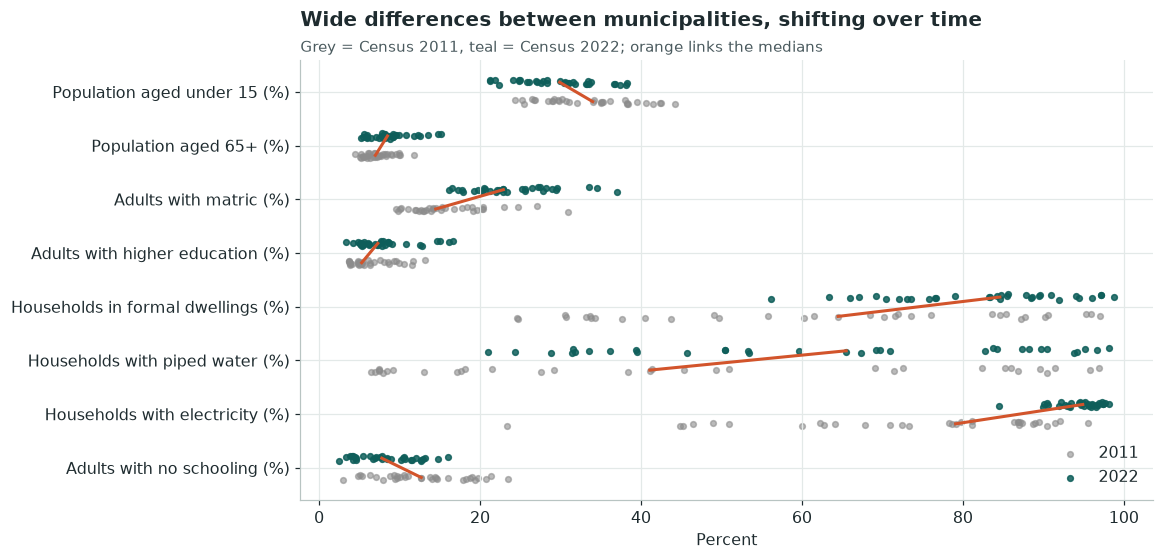

,Median 2011,Median 2022,Municipalities that increased
Population aged under 15 (%),34.0,29.9,0.0
Population aged 65+ (%),7.0,8.5,31.0
Adults with matric (%),14.5,22.9,33.0
Adults with higher education (%),5.3,7.3,30.0
Households in formal dwellings (%),64.5,84.6,33.0
Households with piped water (%),41.1,65.5,31.0
Households with electricity (%),79.1,94.9,33.0
Adults with no schooling (%),12.7,7.8,0.0


In [4]:
show = ["U15", "O65", "Matric", "Higher", "Formal", "Water", "Elec", "NoSch"]
fig, ax = plt.subplots(figsize=(10, 5.2))
for i, m in enumerate(show):
    a, b = census[f"{m}_2011"], census[f"{m}_2022"]
    jitter = np.linspace(-0.12, 0.12, len(census))
    ax.scatter(a, i + 0.18 + jitter * 0.4, s=14, color=C.GREY, alpha=.6, label="2011" if i == 0 else None)
    ax.scatter(b, i - 0.18 + jitter * 0.4, s=14, color=C.TEAL, alpha=.85, label="2022" if i == 0 else None)
    ax.plot([a.median(), b.median()], [i + .18, i - .18], color=C.ALOE, lw=2)
ax.set_yticks(range(len(show))); ax.set_yticklabels([D.FEATURE_LABELS[m] for m in show])
ax.invert_yaxis(); ax.set_xlabel("Percent"); ax.legend(loc="lower right")
ax.set_title("Wide differences between municipalities, shifting over time", pad=22)
subtitle(ax, "Grey = Census 2011, teal = Census 2022; orange links the medians")
save(fig, "census_indicator_spread", "phase2"); plt.show()

chg = pd.DataFrame({D.FEATURE_LABELS[m]: [census[f"{m}_2011"].median(), census[f"{m}_2022"].median(),
                                         (census[f"{m}_2022"] > census[f"{m}_2011"]).sum()] for m in show},
                   index=["Median 2011", "Median 2022", "Municipalities that increased"]).T
display(chg.round(1))

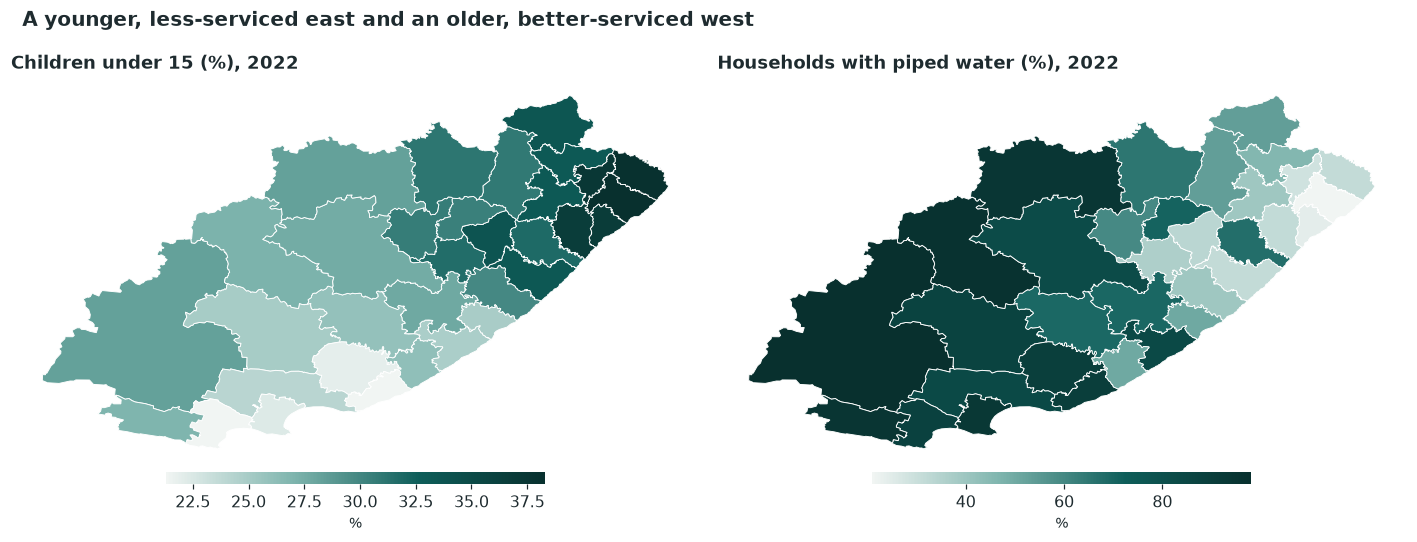

In [5]:
from src.data.geography import load_geojson
geo = load_geojson()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, cmap, title in [(axes[0], "U15", SEQ_CMAP, "Children under 15 (%), 2022"),
                           (axes[1], "Water", SEQ_CMAP, "Households with piped water (%), 2022")]:
    vals = dict(zip(census["MuniCode"], census[f"{m}_2022"]))
    sm = choropleth(ax, geo, vals, cmap=cmap)
    map_colorbar(fig, ax, sm, "%")
    ax.set_title(title, fontsize=11.5)
fig.suptitle("A younger, less-serviced east and an older, better-serviced west",
             x=0.02, y=1.0, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "census_maps_2022", "phase2"); plt.show()

**Reading the maps.** The former Transkei municipalities in the east (O.R. Tambo, Alfred Nzo, Amathole and Chris Hani districts) have much younger populations and lower piped-water access than the western Karoo and coastal municipalities and the two metros. Age structure and service access move together geographically, which matters later: their separate associations with turnout are hard to disentangle with 33 municipalities.

## 3. Aligning Census values to election years: two policies

A census describes one moment. Elections happen at other moments. We use two explicit policies:

| Election | **Descriptive** policy (EDA, Notebook 03) | **As-known** policy (models, Notebooks 04–06) |
|---|---|---|
| 2000, 2006 | not available (no back-extrapolation) | not available |
| 2011 (May) | Census 2011 | not available: Census 2011 was taken in October 2011 and released in 2012 |
| 2016 | interpolated 2011 → 2022 | Census 2011 |
| 2021 | interpolated 2011 → 2022 | Census 2011 |
| 2026 | – | Census 2022 (released October 2023) |

Interpolation (descriptive only): $x_t = x_{2011} + \frac{t-2011}{11}(x_{2022}-x_{2011})$.

The as-known policy is the leakage rule: a model being tested on 2021 must not see a 2022 census.

In [6]:
descriptive = D.align_descriptive(census)
as_known = D.align_as_known(census)
display(descriptive[descriptive["MuniCode"] == "BUF"])
display(as_known[as_known["MuniCode"] == "BUF"])

,MuniCode,Year,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,DemographicStatus
0,BUF,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011
1,BUF,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011
2,BUF,2011,781853.0,26.50,6.10,27.00,5.10,27.10,13.20,71.90,69.10,81.10,Observed_Census2011
3,BUF,2016,869763.0,25.73,6.87,28.36,4.65,30.05,14.02,78.13,75.74,87.24,Interpolated_2011_2022
4,BUF,2021,957673.0,24.95,7.65,29.73,4.19,33.01,14.84,84.35,82.37,93.37,Interpolated_2011_2022


,MuniCode,Year,CensusUsed,K_Pop,K_U15,K_O65,K_Med,K_NoSch,K_Matric,K_Higher,K_Formal,K_Water,K_Elec
0,BUF,2000,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BUF,2006,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BUF,2011,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BUF,2016,2011,781853.0,26.5,6.1,27.0,5.1,27.1,13.2,71.9,69.1,81.1
4,BUF,2021,2011,781853.0,26.5,6.1,27.0,5.1,27.1,13.2,71.9,69.1,81.1
5,BUF,2026,2022,975255.0,24.8,7.8,30.0,4.1,33.6,15.0,85.6,83.7,94.6


## 4. Current profile for 2026 context

In [7]:
current = D.current_profile(census)
current["Municipality"] = current["MuniCode"].map(C.muni_name)
display(current[["MuniCode", "Municipality", "Pop", "PopGrowth_%", "U15", "O65", "Matric", "Water", "Elec"]]
        .sort_values("Pop", ascending=False).head(10))

,MuniCode,Municipality,Pop,PopGrowth_%,U15,O65,Matric,Water,Elec
32,NMA,Nelson Mandela Bay,1190496,3.33,22.3,8.8,37.0,93.8,96.5
0,BUF,Buffalo City,975255,24.74,24.8,7.8,33.6,83.7,94.6
27,EC157,King Sabata Dalindyebo,476558,5.83,31.8,5.9,25.6,67.4,95.1
23,EC153,Ngquza Hill,354573,27.32,38.3,5.4,20.2,21.0,93.2
30,EC443,Winnie Madikizela-Mandela,350000,24.16,38.2,5.2,22.9,31.4,93.3
25,EC155,Nyandeni,304856,4.98,36.7,6.0,21.2,31.8,93.0
19,EC139,Enoch Mgijima,297055,18.45,27.6,8.5,29.4,82.8,96.5
8,EC121,Mbhashe,240020,-8.27,33.4,9.6,16.5,31.5,90.5
9,EC122,Mnquma,232993,-5.14,29.9,10.8,20.6,39.4,94.9
28,EC441,Matatiele,225562,10.65,33.6,8.0,22.0,53.4,84.5


## 5. Gender and age of voters: what is and is not available

The brief's first data source is the IEC voter-registration dashboard (registered voters by municipality, age group and gender). It is a dashboard rather than a download, and the team has not yet extracted it. The pipeline is ready for it: if `data/raw/registration/ec_registration_2026.csv` exists (template in the same folder), it is validated here and used in Notebook 06 to convert turnout scenarios into expected votes.

The repository also contains `EC CENSUS.csv`, an age × sex × population-group table for four censuses. Its totals reveal it is a **Buffalo City** table, not provincial:

In [8]:
reg_path = C.REGISTRATION_2026
if reg_path.exists():
    reg = pd.read_csv(reg_path)
    assert set(reg["MuniCode"]) == C.TARGET_CODES, "Registration file must cover the 33 municipalities"
    print("2026 registration snapshot found:", reg.shape)
    display(reg.head())
else:
    reg = None
    print("No 2026 registration snapshot yet (expected at data/raw/registration/ec_registration_2026.csv).")
    print("Notebook 06 will use 2021 registered voters as a clearly labelled placeholder.")

bufc = pd.read_csv(C.BUF_AGE_SEX_CENSUS)
totals = bufc.groupby("census")["count"].sum().round()
compare = pd.DataFrame({"File total": totals,
                        "Buffalo City population (clean_census)": {2011: census.set_index("MuniCode").loc["BUF", "Pop_2011"],
                                                                   2022: census.set_index("MuniCode").loc["BUF", "Pop_2022"]}})
display(compare)
sex = bufc.groupby(["census", "sex"])["count"].sum().unstack()
print("Female share of Buffalo City population by census (%):", (100 * sex["Female"] / sex.sum(axis=1)).round(1).to_dict())

No 2026 registration snapshot yet (expected at data/raw/registration/ec_registration_2026.csv).
Notebook 06 will use 2021 registered voters as a clearly labelled placeholder.


,File total,Buffalo City population (clean_census)
1996,685727.0,NaN
2001,704855.0,NaN
2011,755200.0,781853.0
2022,975255.0,975255.0


Female share of Buffalo City population by census (%): {1996: 52.8, 2001: 53.1, 2011: 52.5, 2022: 52.7}


The 2022 total equals Buffalo City's 2022 population exactly. The 2011 totals differ (755,200 in this file against 781,853 in `clean_census.csv`); a plausible explanation is that `clean_census.csv` uses Stats SA's re-based 2011 comparison figures, but **the team must confirm which 2011 source was used** before submission. This file shows that municipal age-and-sex breakdowns exist, but one municipality is not enough for a gender analysis across the province, so gender is listed as a limitation and an extension.

## 6. Provenance, metadata and quality control

In [9]:
metadata = pd.DataFrame([{"Feature": k, "Meaning": v, "Descriptive use": "Observed 2011, interpolated 2016/2021",
                          "Model use": "Census 2011 for 2016/2021 targets; Census 2022 for 2026"}
                         for k, v in D.FEATURE_LABELS.items()])
provenance = pd.DataFrame([
    {"Dataset": "clean_census.csv", "Geography": "33 analytical municipalities", "Years": "Census 2011, Census 2022",
     "Role": "Municipal demographic context", "Note": "Upstream source not recorded in the repository; unverified (docs/DATA_SOURCES.md)"},
    {"Dataset": "EC CENSUS.csv", "Geography": "Buffalo City metro (not province)", "Years": "1996, 2001, 2011, 2022",
     "Role": "Illustration only", "Note": "2022 total equals BUF population; not used as provincial evidence"},
    {"Dataset": "ec_registration_2026.csv", "Geography": "33 municipalities", "Years": "2026",
     "Role": "Optional: expected votes in scenarios", "Note": "Present" if reg is not None else "Not yet collected"},
])
qc = pd.DataFrame([
    ("Descriptive rows (33 x 5 elections)", len(descriptive), 165),
    ("As-known rows (33 x 6 elections)", len(as_known), 198),
    ("As-known values for 2011 or earlier", int(as_known.loc[as_known["Year"] <= 2011, [f"K_{m}" for m in D.METRICS]].notna().sum().sum()), 0),
    ("As-known 2016/2021 rows using Census 2011", int((as_known.loc[as_known["Year"].isin([2016, 2021]), "CensusUsed"] == 2011).sum()), 66),
    ("As-known 2026 rows using Census 2022", int((as_known.loc[as_known["Year"] == 2026, "CensusUsed"] == 2022).sum()), 33),
], columns=["Check", "Actual", "Expected"])
qc["Pass"] = qc["Actual"] == qc["Expected"]
display(provenance); display(qc)
assert qc["Pass"].all(), "Phase 2 quality-control gate failed"

,Dataset,Geography,Years,Role,Note
0,clean_census.csv,33 analytical municipalities,"Census 2011, Census 2022",Municipal demographic context,Upstream source not recorded in the repository...
1,EC CENSUS.csv,Buffalo City metro (not province),"1996, 2001, 2011, 2022",Illustration only,2022 total equals BUF population; not used as ...
2,ec_registration_2026.csv,33 municipalities,2026,Optional: expected votes in scenarios,Not yet collected


,Check,Actual,Expected,Pass
0,Descriptive rows (33 x 5 elections),165,165,True
1,As-known rows (33 x 6 elections),198,198,True
2,As-known values for 2011 or earlier,0,0,True
3,As-known 2016/2021 rows using Census 2011,66,66,True
4,As-known 2026 rows using Census 2022,33,33,True


In [10]:
out = C.DIRS["phase2"]
files = {"municipality_census_snapshots_2011_2022.csv": census,
         "demographics_descriptive_2000_2021.csv": descriptive,
         "demographics_as_known_2000_2026.csv": as_known,
         "demographics_current_2022.csv": current,
         "phase2_feature_metadata.csv": metadata,
         "phase2_provenance.csv": provenance,
         "phase2_quality_control.csv": qc}
for name, df in files.items():
    df.to_csv(out / name, index=False); print(f"Saved {name:48s} {len(df):4d} rows")

Saved municipality_census_snapshots_2011_2022.csv        33 rows
Saved demographics_descriptive_2000_2021.csv            165 rows
Saved demographics_as_known_2000_2026.csv               198 rows
Saved demographics_current_2022.csv                      33 rows
Saved phase2_feature_metadata.csv                        10 rows
Saved phase2_provenance.csv                               3 rows
Saved phase2_quality_control.csv                          5 rows


## Summary

- Census context is ready for 33 municipalities, with the **descriptive** and **as-known** policies kept strictly separate.
- No future census information reaches a historical backtest: Census 2011 is the newest input for 2016 and 2021 targets.
- Gaps documented: no province-wide municipal gender data, and the IEC 2026 registration snapshot is still to be collected (the pipeline accepts it when it arrives).

**Limitation.** Municipal averages describe places, not people. A municipality with many young residents and low turnout does not tell us that young residents vote less (the ecological fallacy; Robinson, 1950).

**Next:** Notebook 03 joins elections and demographics into the master panel and asks which municipal characteristics go with higher or lower turnout.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Statistics South Africa. Census 2011 and Census 2022 (https://census.statssa.gov.za). Note: the upstream tables behind data/processed/demographics/clean_census.csv are not recorded in the repository; see docs/DATA_SOURCES.md.
- IEC. Voter Registration Statistics (dashboard). https://www.elections.org.za/pw/StatsData/Voter-Registration-Statistics
- Municipal Demarcation Board 2011 local municipal boundaries, via github.com/datawizzards/zadmaps (geojson/za-local.topojson).
- Robinson, W.S. (1950). Ecological correlations and the behavior of individuals. American Sociological Review, 15(3), 351-357.
- The pandas development team. pandas (software). https://pandas.pydata.org

In [11]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
